## Conducting a LiRA evaluation

In this notebook, we will demonstrate how to use our library to conduct a LiRA evaluation.
Our library enables the evaluation the efficacy of the LiRA method on a certain training algorithm efficiently.

---

### What does it mean to "evaluate" the LiRA method?

Membership Inference Attacks (MIAs) implies attacking a specific target model by training a large number of shadow models that mimic the target model. This setting is costly when the purpose of MIA is evaluating the attack efficacy on a certain training algorithm. 

Therefore, in practice, evaluation can be optimized by training many models and attack all models by using the other models as shadow models.

#### Step-by-Step Explanation of the Process

1. **Dataset Preparation**:  
   Start with a dataset $ D $.
    
    $$
    D = \begin{bmatrix}
    x_1 & x_2 & x_3 & \cdots & x_n
    \end{bmatrix}
    $$

2. **Subset Creation**:  
   Divide the dataset $ D $ into $ M + 1 $ subsets.
   
   Ensure that, in expectation, each target example in $ D $ appears in $ \frac{M+1}{2} $ subsets.  

The subsets $ S_1, S_2, \dots, S_{M+1} $ are created as follows:


\begin{aligned}
S_1 &= \begin{bmatrix} x_1 & \text{NaN} & x_3 & \text{NaN} & \cdots & \text{NaN} \end{bmatrix} \\
S_2 &= \begin{bmatrix} \text{NaN} & x_2 & x_3 & \text{NaN} &  \cdots & \text{NaN} \end{bmatrix} \\
S_3 &= \begin{bmatrix} x_1 & x_2 & \text{NaN} & x_4 &  \cdots & x_n \end{bmatrix} \\
&\vdots \\
S_{M+1} &= \begin{bmatrix} \text{NaN} & \text{NaN} & \text{NaN} & x_4 & \cdots & x_n \end{bmatrix}
\end{aligned}

To represent this in a (num_models, num_examples)-matrix:
\begin{bmatrix}
x_1 & \text{NaN} & x_3 & \cdots & \text{NaN} \\
\text{NaN} & x_2 & x_3 & \cdots & \text{NaN} \\
x_1 & x_2 & \text{NaN} & \cdots & x_n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\text{NaN} & \text{NaN} & \text{NaN} & \cdots & x_n
\end{bmatrix}

3. **Shadow Model Training**:  
   Train $ M + 1 $ models, each on one of the $ M +1 $ subsets of $ D $.
   - This ensures that each target example $ x_i $ has roughly the same number of in-shadow models and out-shadow models ($ \approx \frac{M}{2} $).

4. **Likelihood-Ratio Estimation**:  
   Estimate the likelihood-ratio for all examples in the dataset $ D $.
   - By attacking all $ M $ shadow models for $ n $ examples, we will obtain $ M \times n $ LiRA scores with their corresponding ground truth memberships (`True` or `False`).
---

In [1]:
# Import the library
from mialibrary.data_loader import load_data_lira, save_results
from mialibrary.lira.check_types import check_types
from mialibrary.lira.validate_inputs import validate_inputs
from mialibrary.lira.compute_score import compute_lira_score
from mialibrary.plot import plot_roc_curve, compute_tpr_at_fpr

### Step 1: Load Data

The data consists of:

1. **`stat`**: A 3D array `(num_models, num_examples, num_augmentations)` containing logits computed from the predicted probabilities in the case of classifiers:

$$
\text{logit}(p) = \log\left(\frac{p}{1-p}\right) \\
\text{for } p = f_\theta(x)_y
$$

where $f_\theta(x)_y$ denotes the predicted probability of class $y$.

2. **`in_indices`**: A 2D array `(num_models, num_examples)` with boolean values indicating the memberships, whether the examples are included in the training set.

In [2]:
# Define paths to your data
stat_path = "data_small/stat_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl"
in_indices_path = "data_small/in_indices_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl"

# Load stat and in_indices data from files.
stat, in_indices = load_data_lira(stat_path, in_indices_path)

Data loaded successfully.


### Step 2: Validate the input
This ensures that the input is the intended type and has valid number of in and out shadow models.

The expected format and shapes are:

- `stat`: Pre-computed statistics from model outputs
    - Format: list of NumPy arrays, NumPy arrays, or JAX arrays
    - Shape of stat: (m_models, n_samples, k_augmentations)

- `in_indices`: Training data indices
    - Format: list of NumPy arrays, NumPy arrays, or JAX arrays
    - Shape of in_indices: (m_models, n_samples)
    - Values: Boolean (True: used in training, False: not used)


In [3]:
# Check the types of the input arrays and convert them to numpy arrays.
stat, in_indices = check_types(stat, in_indices)

# Validate the inputs for shape, NaN values, and number of examples. Convert NumPy arrays to JAX arrays after validation.
stat, in_indices = validate_inputs(stat, in_indices, stat_path, in_indices_path)

print(f"Number of models: {stat.shape[0]}, Number of examples: {stat.shape[1]}, Augmentations: {stat.shape[2]}")
print(f"Stat shape: {stat.shape}, In indices shape: {in_indices.shape}")

Number of models: 32, Number of examples: 4096, Augmentations: 1
Stat shape: (32, 4096, 1), In indices shape: (32, 4096)


### Step 3: Compute LiRA Scores

The `compute_lira_score` function calculates the LiRA scores based on the validated `stat` and `in_indices` arrays. 

Explanation of the options:
- **`fix_variance`**: If set to `True`, the variance of the estimated shadow model distribution is calculated globally, using all the examples. The recommended setting is `True` for $ M \leq 64 $ because it is more robust to the outliers that may be present in the case of using per-example variance with fewer shadow models.

- **`use_median`**: If set to `True`, the mean of the estimated shadow model distribution will be median instead of the mean. The recommended setting is `True` because it is more robust to outliers.

\* It is possible that other options enable more powerful attacks depending on the dataset and the training algorithms, so we recommend to test all the options.

In [4]:
scores = compute_lira_score(
    stat, in_indices, fix_variance=True, use_median=True
)
print(f"The shape of the scores should be equivalent to (num_models, num_examples), it is {scores.shape}")
print(scores[0])

Median & Global
The shape of the scores should be equivalent to (num_models, num_examples), it is (32, 4096)
[-0.72363136 -1.67203802  0.07639058 ... -0.00784633 -0.95440167
 -0.40588411]


### Step 4: Save the results

In [5]:
score_path = "data_small/scores_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl"

save_results(score_path, scores, in_indices)

Scores computed and saved successfully to data_small/scores_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl.


### Step 5: Evaluate the results
We evaluate the LiRA method with an ROC curve and TPR at a low FPR.

The ROC curve will show the performance of the attack on a certain training algorithm by aggregating the results from all of shadow models and all of the examples (=M*n scores).

Loading data_small/scores_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl
M=32 N=4096


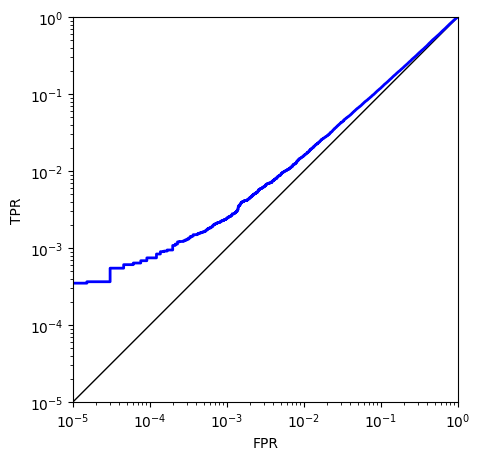

In [6]:
plot_roc_curve(score_path, lowest_fpr_to_plot=1e-5)

In [7]:
fpr_points, tpr_at_fpr = compute_tpr_at_fpr(score_path)

# Print TPR at specific FPR points
print("fpr_points:", fpr_points)
print("tpr_at_fpr:", tpr_at_fpr)

for i in range(len(fpr_points)):
    print(f"\nTPR@FPR={fpr_points[i]} is {tpr_at_fpr[i]:.4f}")


Loading data_small/scores_small_patch_camelyon_vit-b-16_-1_16384_-1.0_22_22.pkl
M=32 N=4096
fpr_points: [0.001, 0.01, 0.1]
tpr_at_fpr: [0.00240934 0.01588948 0.11994876]

TPR@FPR=0.001 is 0.0024

TPR@FPR=0.01 is 0.0159

TPR@FPR=0.1 is 0.1199
